In [2]:
# Autonomous Forest Navigation
# Notebook 02: Sensor Fusion EKF

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Project paths
# ---------------------------------------------------------

CURRENT_DIR = Path.cwd().resolve()

# If the notebook is running from the notebooks folder,
# move one level up to the project root.
if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

SESSION_DIR = (
    DATA_DIR
    / "fomo"
    / "2025-06-26"
    / "green_2025-06-26-11-20"
)

GT_FILE = SESSION_DIR / "gt.txt"
IMU_FILE = SESSION_DIR / "vectornav.csv"
ODOM_FILE = SESSION_DIR / "odom.csv"
GNSS_FILE = SESSION_DIR / "gnss_measurements.csv"

print("SENSOR FUSION PROJECT SETUP")
print("=" * 65)

print("Python       :", sys.executable)
print("Working dir  :", CURRENT_DIR)
print("Project root :", PROJECT_ROOT)
print("Session data :", SESSION_DIR)

print("\nRequired files:")

required_files = [
    GT_FILE,
    IMU_FILE,
    ODOM_FILE,
    GNSS_FILE
]

for file in required_files:
    print(
        f"{file.name:25s} -> "
        f"{'OK' if file.exists() else 'MISSING'}"
    )

SENSOR FUSION PROJECT SETUP
Python       : D:\Autonomous_Forest_Navigation\forest_env\python.exe
Working dir  : D:\Autonomous_Forest_Navigation\notebooks
Project root : D:\Autonomous_Forest_Navigation
Session data : D:\Autonomous_Forest_Navigation\data\fomo\2025-06-26\green_2025-06-26-11-20

Required files:
gt.txt                    -> OK
vectornav.csv             -> OK
odom.csv                  -> OK
gnss_measurements.csv     -> OK


In [3]:
# Load the localization datasets for sensor fusion

# ---------------------------------------------------------
# 1. PPK ground truth
# ---------------------------------------------------------

gt_columns = [
    "timestamp",
    "x", "y", "z",
    "qx", "qy", "qz", "qw"
]

gt = pd.read_csv(
    GT_FILE,
    sep=r"\s+",
    names=gt_columns
)

# Local map coordinates starting near (0, 0)
gt["x_local"] = gt["x"] - gt["x"].iloc[0]
gt["y_local"] = gt["y"] - gt["y"].iloc[0]


# ---------------------------------------------------------
# 2. VectorNav IMU
# ---------------------------------------------------------

imu = pd.read_csv(IMU_FILE)

# Raw timestamps are in microseconds
imu["timestamp"] = imu["t"] / 1e6


# ---------------------------------------------------------
# 3. Robot odometry
# ---------------------------------------------------------

odom = pd.read_csv(ODOM_FILE)

odom["timestamp"] = odom["t"] / 1e6

# Remove completely empty columns
empty_odom_columns = [
    col for col in odom.columns
    if odom[col].isna().all()
]

odom = odom.drop(
    columns=empty_odom_columns
)


# ---------------------------------------------------------
# 4. Prepared GNSS measurements
# ---------------------------------------------------------

gnss = pd.read_csv(GNSS_FILE)

# Make sure availability is boolean
if gnss["available"].dtype != bool:
    gnss["available"] = (
        gnss["available"]
        .astype(str)
        .str.lower()
        .eq("true")
    )


# ---------------------------------------------------------
# 5. Helper for timing summary
# ---------------------------------------------------------

def stream_summary(name, df, time_col="timestamp"):

    timestamps = df[time_col].to_numpy()

    duration = timestamps[-1] - timestamps[0]

    dt = np.diff(timestamps)
    valid_dt = dt[dt > 0]

    if len(valid_dt) > 0:
        rate = 1.0 / np.median(valid_dt)
    else:
        rate = np.nan

    print(f"{name:15s}")
    print(f"  Samples       : {len(df):,}")
    print(f"  Start         : {timestamps[0]:.6f}")
    print(f"  End           : {timestamps[-1]:.6f}")
    print(f"  Duration      : {duration:.2f} s")
    print(f"  Approx. rate  : {rate:.2f} Hz")
    print()


# ---------------------------------------------------------
# 6. Dataset summary
# ---------------------------------------------------------

print("SENSOR FUSION DATA LOADED")
print("=" * 65)
print()

stream_summary("PPK ground truth", gt)
stream_summary("VectorNav IMU", imu)
stream_summary("Odometry", odom)
stream_summary("GNSS", gnss)


print("GNSS availability")
print("=" * 65)

print(
    f"Available : {gnss['available'].sum():,}"
)

print(
    f"Dropouts  : {(~gnss['available']).sum():,}"
)

print("\nOdometry columns:")
print(list(odom.columns))

SENSOR FUSION DATA LOADED

PPK ground truth
  Samples       : 7,504
  Start         : 1750951238.995000
  End           : 1750951989.295000
  Duration      : 750.30 s
  Approx. rate  : 10.00 Hz

VectorNav IMU  
  Samples       : 150,035
  Start         : 1750951238.935009
  End           : 1750951989.315341
  Duration      : 750.38 s
  Approx. rate  : 199.96 Hz

Odometry       
  Samples       : 9,790
  Start         : 1750951239.107009
  End           : 1750951989.225227
  Duration      : 750.12 s
  Approx. rate  : 10.23 Hz

GNSS           
  Samples       : 7,504
  Start         : 1750951238.995000
  End           : 1750951989.295000
  Duration      : 750.30 s
  Approx. rate  : 10.00 Hz

GNSS availability
Available : 7,458
Dropouts  : 46

Odometry columns:
['t', 'px', 'py', 'pz', 'qx', 'qy', 'qz', 'qw', 'tlx', 'tly', 'tlz', 'tax', 'tay', 'taz', 'timestamp']


In [4]:
# Build the synchronized high-rate timeline used by the EKF

# ---------------------------------------------------------
# 1. Determine common time interval
# ---------------------------------------------------------

common_start = max(
    imu["timestamp"].iloc[0],
    odom["timestamp"].iloc[0],
    gnss["timestamp"].iloc[0],
    gt["timestamp"].iloc[0]
)

common_end = min(
    imu["timestamp"].iloc[-1],
    odom["timestamp"].iloc[-1],
    gnss["timestamp"].iloc[-1],
    gt["timestamp"].iloc[-1]
)

print("COMMON SENSOR INTERVAL")
print("=" * 70)

print(f"Start    : {common_start:.6f}")
print(f"End      : {common_end:.6f}")
print(f"Duration : {common_end - common_start:.2f} s")


# ---------------------------------------------------------
# 2. Use IMU timestamps as EKF prediction timeline
# ---------------------------------------------------------

ekf_data = imu[
    (imu["timestamp"] >= common_start) &
    (imu["timestamp"] <= common_end)
].copy()

ekf_data = ekf_data.reset_index(drop=True)

ekf_data["time_s"] = (
    ekf_data["timestamp"] -
    common_start
)

print("\nEKF TIMELINE")
print("=" * 70)

print(f"Prediction steps : {len(ekf_data):,}")


# ---------------------------------------------------------
# 3. Calculate robot speed from odometry
# ---------------------------------------------------------

odom_speed = np.sqrt(
    odom["tlx"].to_numpy() ** 2 +
    odom["tly"].to_numpy() ** 2 +
    odom["tlz"].to_numpy() ** 2
)

# Interpolate odometry speed to IMU timestamps
ekf_data["speed"] = np.interp(
    ekf_data["timestamp"].to_numpy(),
    odom["timestamp"].to_numpy(),
    odom_speed
)


# ---------------------------------------------------------
# 4. VectorNav wz is our yaw-rate measurement
# ---------------------------------------------------------

ekf_data["yaw_rate"] = ekf_data["wz"]


# ---------------------------------------------------------
# 5. Prepare empty GNSS correction columns
# ---------------------------------------------------------

ekf_data["gnss_x"] = np.nan
ekf_data["gnss_y"] = np.nan
ekf_data["gnss_sigma"] = np.nan
ekf_data["gnss_available"] = False
ekf_data["gnss_solution"] = None


# ---------------------------------------------------------
# 6. Match each GNSS update to nearest IMU timestamp
# ---------------------------------------------------------

imu_times = ekf_data["timestamp"].to_numpy()

gnss_common = gnss[
    (gnss["timestamp"] >= common_start) &
    (gnss["timestamp"] <= common_end)
].copy()

mapped_updates = 0
mapped_available = 0
alignment_errors = []

for _, row in gnss_common.iterrows():

    timestamp = row["timestamp"]

    idx = np.searchsorted(
        imu_times,
        timestamp
    )

    # Find nearest IMU sample
    candidates = []

    if idx < len(imu_times):
        candidates.append(idx)

    if idx > 0:
        candidates.append(idx - 1)

    nearest_idx = min(
        candidates,
        key=lambda i: abs(
            imu_times[i] - timestamp
        )
    )

    time_error = abs(
        imu_times[nearest_idx] -
        timestamp
    )

    alignment_errors.append(time_error)

    # GNSS and IMU are synchronized well enough that
    # this should always be comfortably below 0.01 s
    if time_error <= 0.01:

        mapped_updates += 1

        ekf_data.at[
            nearest_idx,
            "gnss_solution"
        ] = row["solution"]

        ekf_data.at[
            nearest_idx,
            "gnss_sigma"
        ] = row["sigma_m"]

        if bool(row["available"]):

            ekf_data.at[
                nearest_idx,
                "gnss_x"
            ] = row["gnss_x"]

            ekf_data.at[
                nearest_idx,
                "gnss_y"
            ] = row["gnss_y"]

            ekf_data.at[
                nearest_idx,
                "gnss_available"
            ] = True

            mapped_available += 1


# ---------------------------------------------------------
# 7. Time-step statistics
# ---------------------------------------------------------

ekf_dt = np.diff(
    ekf_data["timestamp"].to_numpy()
)

print("\nTIMING")
print("=" * 70)

print(
    f"Median EKF dt          : "
    f"{np.median(ekf_dt):.6f} s"
)

print(
    f"Prediction frequency   : "
    f"{1 / np.median(ekf_dt):.2f} Hz"
)

print(
    f"Maximum EKF dt         : "
    f"{np.max(ekf_dt):.6f} s"
)


# ---------------------------------------------------------
# 8. Synchronization summary
# ---------------------------------------------------------

print("\nGNSS → IMU SYNCHRONIZATION")
print("=" * 70)

print(
    f"GNSS updates in interval : "
    f"{len(gnss_common):,}"
)

print(
    f"GNSS updates mapped      : "
    f"{mapped_updates:,}"
)

print(
    f"Available corrections    : "
    f"{mapped_available:,}"
)

print(
    f"Maximum alignment error  : "
    f"{max(alignment_errors) * 1000:.3f} ms"
)


# ---------------------------------------------------------
# 9. Control-input summary
# ---------------------------------------------------------

print("\nEKF CONTROL INPUTS")
print("=" * 70)

print(
    f"Mean speed       : "
    f"{ekf_data['speed'].mean():.3f} m/s"
)

print(
    f"Maximum speed    : "
    f"{ekf_data['speed'].max():.3f} m/s"
)

print(
    f"Yaw-rate minimum : "
    f"{ekf_data['yaw_rate'].min():.3f} rad/s"
)

print(
    f"Yaw-rate maximum : "
    f"{ekf_data['yaw_rate'].max():.3f} rad/s"
)

print("\nFirst 5 EKF timeline rows:")

display(
    ekf_data[
        [
            "time_s",
            "speed",
            "yaw_rate",
            "gnss_x",
            "gnss_y",
            "gnss_sigma",
            "gnss_available"
        ]
    ].head()
)

COMMON SENSOR INTERVAL
Start    : 1750951239.107009
End      : 1750951989.225227
Duration : 750.12 s

EKF TIMELINE
Prediction steps : 149,981

TIMING
Median EKF dt          : 0.005001 s
Prediction frequency   : 199.96 Hz
Maximum EKF dt         : 0.005010 s

GNSS → IMU SYNCHRONIZATION
GNSS updates in interval : 7,501
GNSS updates mapped      : 7,501
Available corrections    : 7,455
Maximum alignment error  : 2.500 ms

EKF CONTROL INPUTS
Mean speed       : 1.101 m/s
Maximum speed    : 2.602 m/s
Yaw-rate minimum : -0.534 rad/s
Yaw-rate maximum : 0.568 rad/s

First 5 EKF timeline rows:


,time_s,speed,yaw_rate,gnss_x,gnss_y,gnss_sigma,gnss_available
0,0.003061,0.0,-0.011436,NaN,NaN,NaN,False
1,0.008063,0.0,-0.010969,NaN,NaN,NaN,False
2,0.013065,0.0,-0.009940,NaN,NaN,NaN,False
3,0.018067,0.0,-0.010636,NaN,NaN,NaN,False
4,0.023068,0.0,-0.011108,NaN,NaN,NaN,False


INITIAL HEADING BOOTSTRAP
Motion detected at : 2.894 s
Heading segment duration : 2.894 s
Heading segment distance : 4.015 m
Initial heading          : 29.939 deg
EKF start time           : 5.788 s

INITIAL EKF STATE
X   : 4.596 m
Y   : 2.682 m
Yaw : 0.52254 rad
Yaw : 29.939 deg


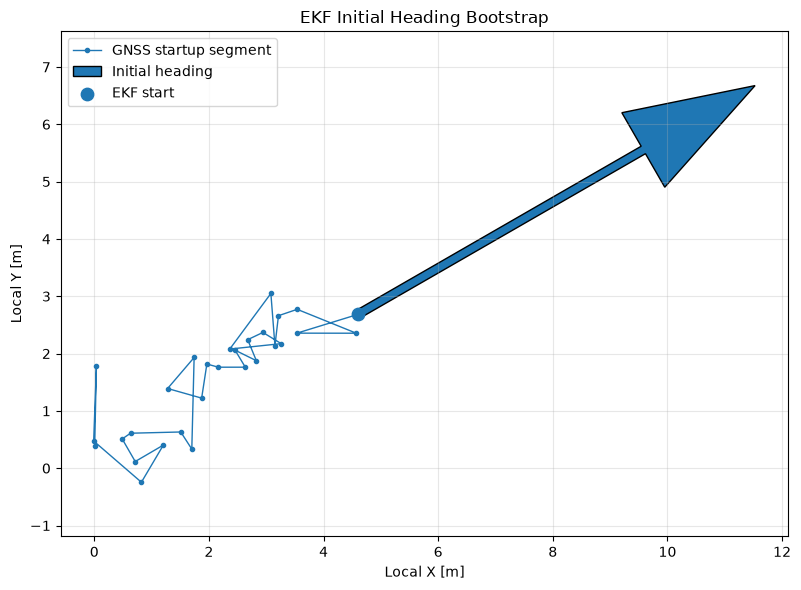


Figure saved to:
D:\Autonomous_Forest_Navigation\figures\green_ekf_initial_heading.png


In [5]:
# Estimate the initial map-frame heading from the first
# short moving segment of the GNSS measurement stream.
#
# PPK ground truth is NOT used here.

# ---------------------------------------------------------
# 1. Find when the robot first begins moving
# ---------------------------------------------------------

MOVING_SPEED_THRESHOLD = 0.30   # m/s

moving_rows = ekf_data[
    ekf_data["speed"] >= MOVING_SPEED_THRESHOLD
]

if len(moving_rows) == 0:
    raise RuntimeError("Could not detect robot motion.")

movement_start_time = (
    moving_rows["timestamp"].iloc[0]
)

print("INITIAL HEADING BOOTSTRAP")
print("=" * 70)

print(
    f"Motion detected at : "
    f"{movement_start_time - common_start:.3f} s"
)


# ---------------------------------------------------------
# 2. Use only real available GNSS measurement updates
# ---------------------------------------------------------

gnss_heading = gnss_common[
    (gnss_common["available"]) &
    (gnss_common["timestamp"] >= movement_start_time)
].copy()

gnss_heading = gnss_heading.dropna(
    subset=["gnss_x", "gnss_y"]
).reset_index(drop=True)

if len(gnss_heading) < 10:
    raise RuntimeError(
        "Not enough GNSS measurements for heading initialization."
    )


# ---------------------------------------------------------
# 3. Find a short trajectory segment with enough displacement
# ---------------------------------------------------------

HEADING_DISTANCE = 5.0   # metres

start_xy = gnss_heading.loc[
    0,
    ["gnss_x", "gnss_y"]
].to_numpy(dtype=float)

all_xy = gnss_heading[
    ["gnss_x", "gnss_y"]
].to_numpy()

distance_from_start = np.linalg.norm(
    all_xy - start_xy,
    axis=1
)

valid_end_indices = np.where(
    distance_from_start >= HEADING_DISTANCE
)[0]

if len(valid_end_indices) == 0:
    raise RuntimeError(
        "Robot did not move far enough to estimate heading."
    )

heading_end_idx = valid_end_indices[0]

heading_segment = gnss_heading.iloc[
    :heading_end_idx + 1
].copy()


# ---------------------------------------------------------
# 4. Average the beginning/end of the segment
#    to reduce GNSS measurement noise
# ---------------------------------------------------------

N_AVG = min(
    5,
    max(1, len(heading_segment) // 4)
)

start_mean = heading_segment[
    ["gnss_x", "gnss_y"]
].iloc[:N_AVG].mean().to_numpy()

end_mean = heading_segment[
    ["gnss_x", "gnss_y"]
].iloc[-N_AVG:].mean().to_numpy()

direction = end_mean - start_mean

initial_yaw = np.arctan2(
    direction[1],
    direction[0]
)

initial_yaw_deg = np.degrees(
    initial_yaw
)


# ---------------------------------------------------------
# 5. Start the EKF at the END of this bootstrap segment
# ---------------------------------------------------------

bootstrap_end = heading_segment.iloc[-1]

FILTER_START_TIMESTAMP = float(
    bootstrap_end["timestamp"]
)

initial_x = float(
    bootstrap_end["gnss_x"]
)

initial_y = float(
    bootstrap_end["gnss_y"]
)

initial_state = np.array([
    initial_x,
    initial_y,
    initial_yaw
])


# ---------------------------------------------------------
# 6. Summary
# ---------------------------------------------------------

bootstrap_duration = (
    FILTER_START_TIMESTAMP -
    movement_start_time
)

bootstrap_distance = np.linalg.norm(
    end_mean - start_mean
)

print(
    f"Heading segment duration : "
    f"{bootstrap_duration:.3f} s"
)

print(
    f"Heading segment distance : "
    f"{bootstrap_distance:.3f} m"
)

print(
    f"Initial heading          : "
    f"{initial_yaw_deg:.3f} deg"
)

print(
    f"EKF start time           : "
    f"{FILTER_START_TIMESTAMP - common_start:.3f} s"
)

print("\nINITIAL EKF STATE")
print("=" * 70)

print(f"X   : {initial_state[0]:.3f} m")
print(f"Y   : {initial_state[1]:.3f} m")
print(f"Yaw : {initial_state[2]:.5f} rad")
print(f"Yaw : {initial_yaw_deg:.3f} deg")


# ---------------------------------------------------------
# 7. Visual verification
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    heading_segment["gnss_x"],
    heading_segment["gnss_y"],
    marker=".",
    linewidth=1,
    label="GNSS startup segment"
)

arrow_length = 8.0

ax.arrow(
    initial_x,
    initial_y,
    arrow_length * np.cos(initial_yaw),
    arrow_length * np.sin(initial_yaw),
    width=0.15,
    head_width=1.5,
    length_includes_head=True,
    label="Initial heading"
)

ax.scatter(
    initial_x,
    initial_y,
    s=80,
    marker="o",
    zorder=5,
    label="EKF start"
)

ax.set_title(
    "EKF Initial Heading Bootstrap"
)

ax.set_xlabel("Local X [m]")
ax.set_ylabel("Local Y [m]")

ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

heading_figure = (
    FIGURES_DIR /
    "green_ekf_initial_heading.png"
)

plt.savefig(
    heading_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(heading_figure)

In [6]:
# Define the planar Extended Kalman Filter model
#
# State:
#     [x, y, yaw]
#
# Inputs:
#     v     = odometry linear speed
#     omega = VectorNav yaw rate (wz)
#
# Measurement:
#     GNSS x, y position

import numpy as np


# ---------------------------------------------------------
# 1. Utility: keep angles between -pi and +pi
# ---------------------------------------------------------

def wrap_angle(angle):
    return (angle + np.pi) % (2.0 * np.pi) - np.pi


# ---------------------------------------------------------
# 2. EKF prediction model
# ---------------------------------------------------------

def ekf_predict(
    state,
    covariance,
    speed,
    yaw_rate,
    dt,
    sigma_speed=0.20,
    sigma_yaw_rate=0.04
):
    """
    EKF prediction using:
        x_next   = x + v*cos(yaw)*dt
        y_next   = y + v*sin(yaw)*dt
        yaw_next = yaw + omega*dt
    """

    x, y, yaw = state

    # -----------------------------
    # Nonlinear state prediction
    # -----------------------------

    predicted_state = np.array([
        x + speed * np.cos(yaw) * dt,
        y + speed * np.sin(yaw) * dt,
        wrap_angle(yaw + yaw_rate * dt)
    ])


    # -----------------------------
    # Jacobian with respect to state
    # -----------------------------

    F = np.array([
        [
            1.0,
            0.0,
            -speed * np.sin(yaw) * dt
        ],
        [
            0.0,
            1.0,
            speed * np.cos(yaw) * dt
        ],
        [
            0.0,
            0.0,
            1.0
        ]
    ])


    # -----------------------------
    # Jacobian with respect to
    # control noise [v, omega]
    # -----------------------------

    G = np.array([
        [
            np.cos(yaw) * dt,
            0.0
        ],
        [
            np.sin(yaw) * dt,
            0.0
        ],
        [
            0.0,
            dt
        ]
    ])


    # Control-input uncertainty
    M = np.diag([
        sigma_speed ** 2,
        sigma_yaw_rate ** 2
    ])


    # Process covariance
    Q = G @ M @ G.T

    # Small numerical/model floor
    Q += np.diag([
        1e-6,
        1e-6,
        np.deg2rad(0.01) ** 2
    ])


    predicted_covariance = (
        F @ covariance @ F.T +
        Q
    )

    return predicted_state, predicted_covariance


# ---------------------------------------------------------
# 3. EKF GNSS correction
# ---------------------------------------------------------

def ekf_update_gnss(
    state,
    covariance,
    measurement_x,
    measurement_y,
    measurement_sigma
):
    """
    Correct EKF position using GNSS x/y measurement.
    """

    z = np.array([
        measurement_x,
        measurement_y
    ])

    # Measurement model:
    # GNSS directly observes x and y
    H = np.array([
        [1.0, 0.0, 0.0],
        [0.0, 1.0, 0.0]
    ])

    predicted_measurement = H @ state

    innovation = (
        z -
        predicted_measurement
    )

    # Dynamic GNSS covariance
    R = np.diag([
        measurement_sigma ** 2,
        measurement_sigma ** 2
    ])

    innovation_covariance = (
        H @ covariance @ H.T +
        R
    )

    kalman_gain = (
        covariance @
        H.T @
        np.linalg.inv(innovation_covariance)
    )

    updated_state = (
        state +
        kalman_gain @ innovation
    )

    updated_state[2] = wrap_angle(
        updated_state[2]
    )

    I = np.eye(3)

    # Joseph covariance form:
    # numerically safer than P = (I-KH)P
    updated_covariance = (
        (I - kalman_gain @ H)
        @ covariance
        @ (I - kalman_gain @ H).T
        +
        kalman_gain
        @ R
        @ kalman_gain.T
    )

    return (
        updated_state,
        updated_covariance,
        innovation,
        kalman_gain
    )


# ---------------------------------------------------------
# 4. Initial covariance
# ---------------------------------------------------------

INITIAL_POSITION_STD = 1.0
INITIAL_HEADING_STD_DEG = 15.0

initial_covariance = np.diag([
    INITIAL_POSITION_STD ** 2,
    INITIAL_POSITION_STD ** 2,
    np.deg2rad(INITIAL_HEADING_STD_DEG) ** 2
])


# ---------------------------------------------------------
# 5. Display configuration
# ---------------------------------------------------------

print("EKF MODEL CONFIGURATION")
print("=" * 70)

print("State:")
print("  [x, y, yaw]")

print("\nPrediction inputs:")
print("  Odometry speed")
print("  VectorNav wz yaw rate")

print("\nCorrection:")
print("  Quality-aware GNSS x/y")

print("\nProcess-noise assumptions:")
print("  Speed std       : 0.20 m/s")
print("  Yaw-rate std    : 0.04 rad/s")

print("\nInitial uncertainty:")
print(
    f"  Position std    : "
    f"{INITIAL_POSITION_STD:.2f} m"
)

print(
    f"  Heading std     : "
    f"{INITIAL_HEADING_STD_DEG:.1f} deg"
)

print("\nInitial covariance matrix:")
print(initial_covariance)

EKF MODEL CONFIGURATION
State:
  [x, y, yaw]

Prediction inputs:
  Odometry speed
  VectorNav wz yaw rate

Correction:
  Quality-aware GNSS x/y

Process-noise assumptions:
  Speed std       : 0.20 m/s
  Yaw-rate std    : 0.04 rad/s

Initial uncertainty:
  Position std    : 1.00 m
  Heading std     : 15.0 deg

Initial covariance matrix:
[[1.         0.         0.        ]
 [0.         1.         0.        ]
 [0.         0.         0.06853892]]


In [7]:
# Run the Extended Kalman Filter over the complete forest trajectory

# ---------------------------------------------------------
# 1. Keep data from the EKF initialization time onward
# ---------------------------------------------------------

filter_data = ekf_data[
    ekf_data["timestamp"] >= FILTER_START_TIMESTAMP
].copy().reset_index(drop=True)

filter_times = filter_data["timestamp"].to_numpy()

print("RUNNING SENSOR-FUSION EKF")
print("=" * 70)

print(f"Filter steps : {len(filter_data):,}")
print(
    f"Duration     : "
    f"{filter_times[-1] - filter_times[0]:.2f} s"
)


# ---------------------------------------------------------
# 2. Initialize EKF
# ---------------------------------------------------------

state = initial_state.copy()
covariance = initial_covariance.copy()

num_steps = len(filter_data)

# Store fused trajectory
ekf_states = np.zeros(
    (num_steps, 3)
)

# Store dead-reckoning trajectory for comparison
dr_states = np.zeros(
    (num_steps, 3)
)

# Covariance history
ekf_std = np.zeros(
    (num_steps, 3)
)

# GNSS innovation magnitude
innovation_norm = np.full(
    num_steps,
    np.nan
)

# Initial dead-reckoning state
dr_state = initial_state.copy()

gnss_corrections = 0


# ---------------------------------------------------------
# 3. Run EKF
# ---------------------------------------------------------

for k in range(num_steps):

    row = filter_data.iloc[k]

    # ---------------------------------------------
    # Time step
    # ---------------------------------------------

    if k == 0:

        dt = 0.0

    else:

        dt = (
            filter_times[k] -
            filter_times[k - 1]
        )


    speed = float(
        row["speed"]
    )

    yaw_rate = float(
        row["yaw_rate"]
    )


    # ---------------------------------------------
    # EKF prediction
    # ---------------------------------------------

    if dt > 0:

        state, covariance = ekf_predict(
            state=state,
            covariance=covariance,
            speed=speed,
            yaw_rate=yaw_rate,
            dt=dt
        )


        # -----------------------------------------
        # Dead-reckoning baseline
        # Same motion model, but NO GNSS correction
        # -----------------------------------------

        x_dr, y_dr, yaw_dr = dr_state

        dr_state = np.array([
            x_dr
            + speed
            * np.cos(yaw_dr)
            * dt,

            y_dr
            + speed
            * np.sin(yaw_dr)
            * dt,

            wrap_angle(
                yaw_dr
                + yaw_rate * dt
            )
        ])


    # ---------------------------------------------
    # GNSS correction
    # ---------------------------------------------

    if bool(
        row["gnss_available"]
    ):

        if (
            np.isfinite(row["gnss_x"])
            and np.isfinite(row["gnss_y"])
            and np.isfinite(row["gnss_sigma"])
        ):

            state, covariance, innovation, K = (
                ekf_update_gnss(
                    state=state,
                    covariance=covariance,
                    measurement_x=float(
                        row["gnss_x"]
                    ),
                    measurement_y=float(
                        row["gnss_y"]
                    ),
                    measurement_sigma=float(
                        row["gnss_sigma"]
                    )
                )
            )

            innovation_norm[k] = (
                np.linalg.norm(
                    innovation
                )
            )

            gnss_corrections += 1


    # ---------------------------------------------
    # Save state
    # ---------------------------------------------

    ekf_states[k] = state

    dr_states[k] = dr_state

    ekf_std[k] = np.sqrt(
        np.diag(covariance)
    )


# ---------------------------------------------------------
# 4. Interpolate PPK ground truth to EKF timestamps
# ---------------------------------------------------------

gt_eval_x = np.interp(
    filter_times,
    gt["timestamp"].to_numpy(),
    gt["x_local"].to_numpy()
)

gt_eval_y = np.interp(
    filter_times,
    gt["timestamp"].to_numpy(),
    gt["y_local"].to_numpy()
)

gt_eval = np.column_stack([
    gt_eval_x,
    gt_eval_y
])


# ---------------------------------------------------------
# 5. Calculate fused-position error
# ---------------------------------------------------------

ekf_xy = ekf_states[:, :2]

ekf_error = np.linalg.norm(
    ekf_xy - gt_eval,
    axis=1
)


# ---------------------------------------------------------
# 6. Dead-reckoning error
# ---------------------------------------------------------

dr_xy = dr_states[:, :2]

dr_error = np.linalg.norm(
    dr_xy - gt_eval,
    axis=1
)


# ---------------------------------------------------------
# 7. Summary statistics
# ---------------------------------------------------------

def error_summary(
    name,
    errors
):

    rmse = np.sqrt(
        np.mean(errors ** 2)
    )

    print(name)
    print("-" * 70)

    print(
        f"RMSE         : "
        f"{rmse:.3f} m"
    )

    print(
        f"Mean error   : "
        f"{errors.mean():.3f} m"
    )

    print(
        f"Median error : "
        f"{np.median(errors):.3f} m"
    )

    print(
        f"Maximum error: "
        f"{errors.max():.3f} m"
    )

    print(
        f"Final error  : "
        f"{errors[-1]:.3f} m"
    )

    print()

    return rmse


print("\nFILTER EXECUTION COMPLETE")
print("=" * 70)

print(
    f"GNSS corrections used : "
    f"{gnss_corrections:,}"
)

print()

dr_rmse = error_summary(
    "DEAD RECKONING",
    dr_error
)

ekf_rmse = error_summary(
    "EKF SENSOR FUSION",
    ekf_error
)


# ---------------------------------------------------------
# 8. Calculate improvement
# ---------------------------------------------------------

improvement = (
    100.0 *
    (dr_rmse - ekf_rmse)
    / dr_rmse
)

print(
    "RMSE improvement over dead reckoning:"
)

print(
    f"{improvement:.2f} %"
)

RUNNING SENSOR-FUSION EKF
Filter steps : 148,824
Duration     : 744.32 s

FILTER EXECUTION COMPLETE
GNSS corrections used : 7,398

DEAD RECKONING
----------------------------------------------------------------------
RMSE         : 301.471 m
Mean error   : 254.638 m
Median error : 198.013 m
Maximum error: 574.731 m
Final error  : 533.457 m

EKF SENSOR FUSION
----------------------------------------------------------------------
RMSE         : 0.749 m
Mean error   : 0.697 m
Median error : 0.665 m
Maximum error: 3.254 m
Final error  : 1.091 m

RMSE improvement over dead reckoning:
99.75 %


LOCALIZATION PERFORMANCE COMPARISON


,Method,RMSE [m],Mean Error [m],Maximum Error [m]
0,Dead Reckoning,301.471,254.638,574.731
1,GNSS Only,1.095,0.727,18.905
2,EKF Sensor Fusion,0.749,0.697,3.254


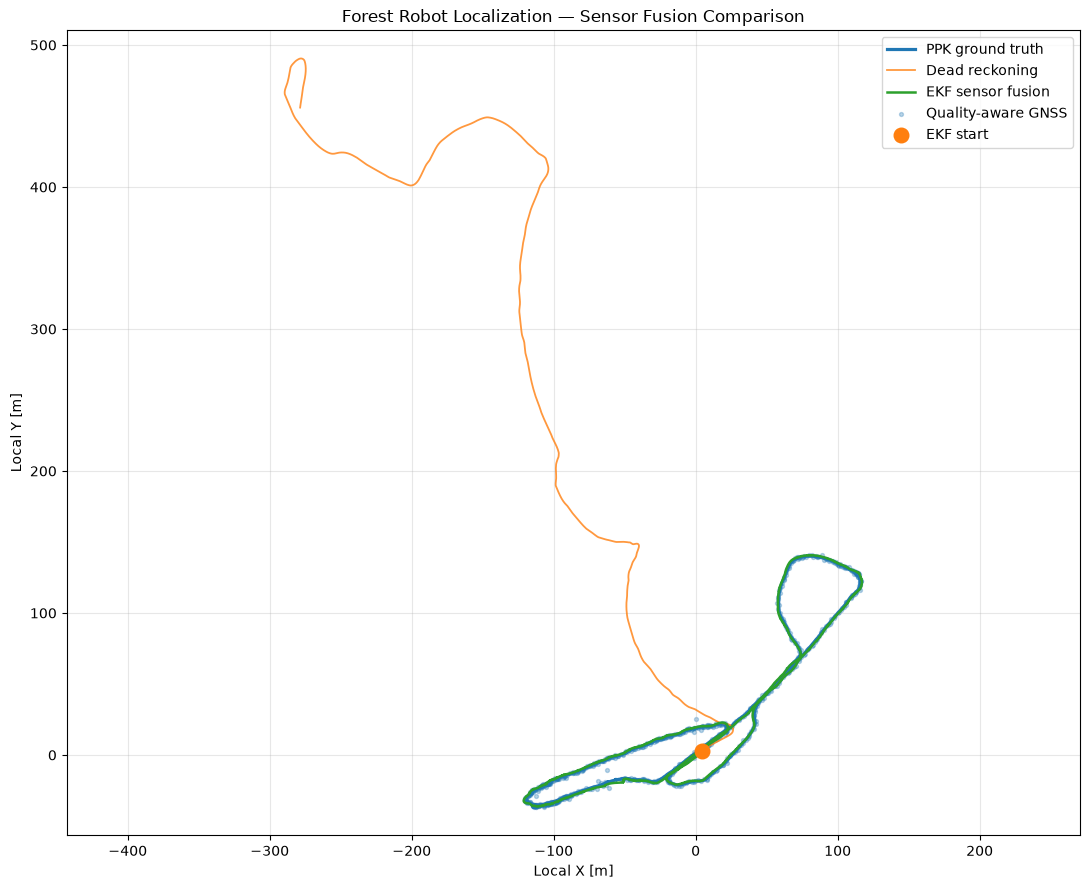

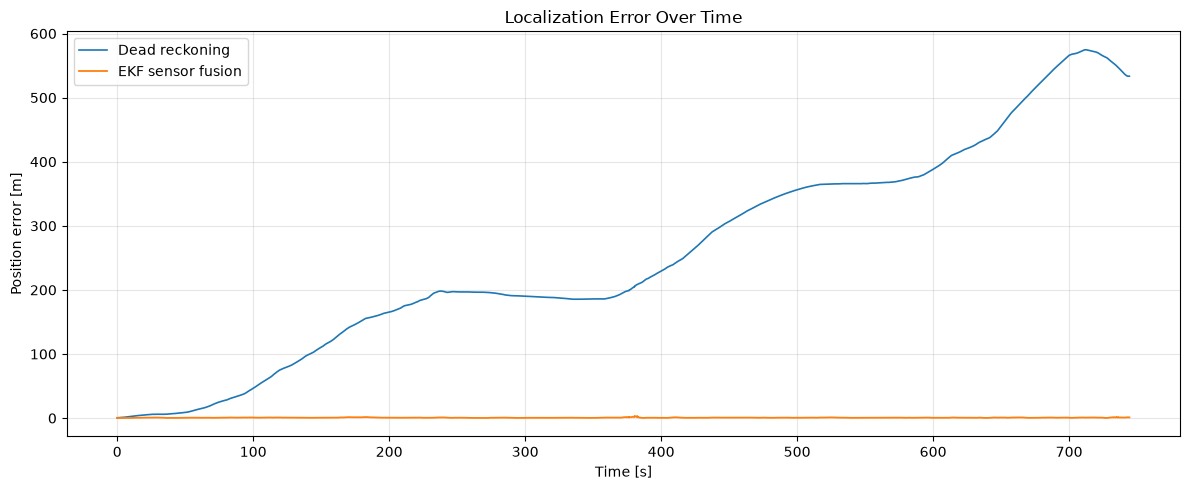

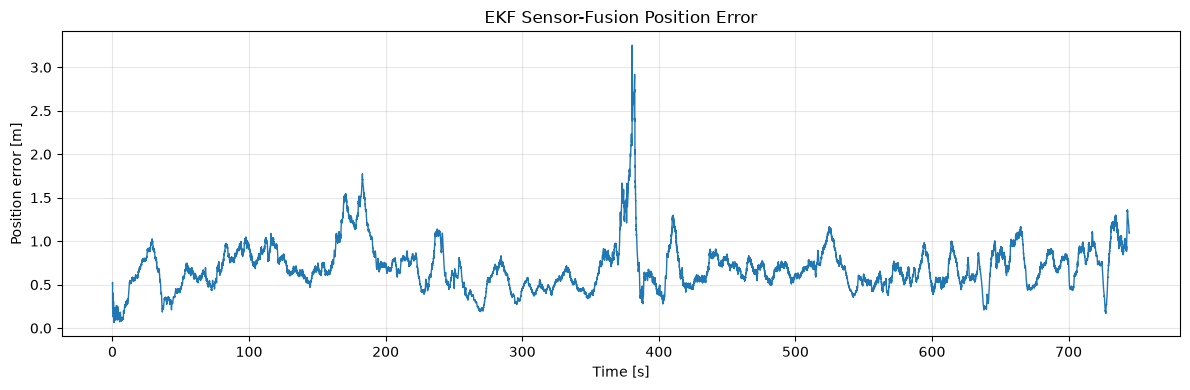


Figures saved:
D:\Autonomous_Forest_Navigation\figures\green_localization_comparison.png
D:\Autonomous_Forest_Navigation\figures\green_localization_error_comparison.png
D:\Autonomous_Forest_Navigation\figures\green_ekf_position_error.png


In [8]:
# Compare localization methods against PPK ground truth

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Relative time
# ---------------------------------------------------------

filter_time_rel = (
    filter_times -
    filter_times[0]
)


# ---------------------------------------------------------
# 2. Prepare GNSS measurements inside EKF evaluation interval
# ---------------------------------------------------------

gnss_eval = gnss[
    (gnss["timestamp"] >= filter_times[0]) &
    (gnss["timestamp"] <= filter_times[-1]) &
    (gnss["available"])
].copy()

gnss_eval = gnss_eval.dropna(
    subset=["gnss_x", "gnss_y"]
)


# ---------------------------------------------------------
# 3. GNSS-only error on same interval
# ---------------------------------------------------------

gnss_gt_x = np.interp(
    gnss_eval["timestamp"].to_numpy(),
    gt["timestamp"].to_numpy(),
    gt["x_local"].to_numpy()
)

gnss_gt_y = np.interp(
    gnss_eval["timestamp"].to_numpy(),
    gt["timestamp"].to_numpy(),
    gt["y_local"].to_numpy()
)

gnss_error_eval = np.sqrt(
    (gnss_eval["gnss_x"].to_numpy() - gnss_gt_x) ** 2 +
    (gnss_eval["gnss_y"].to_numpy() - gnss_gt_y) ** 2
)

gnss_rmse_eval = np.sqrt(
    np.mean(
        gnss_error_eval ** 2
    )
)


# ---------------------------------------------------------
# 4. Summary table
# ---------------------------------------------------------

results = pd.DataFrame({
    "Method": [
        "Dead Reckoning",
        "GNSS Only",
        "EKF Sensor Fusion"
    ],
    "RMSE [m]": [
        dr_rmse,
        gnss_rmse_eval,
        ekf_rmse
    ],
    "Mean Error [m]": [
        dr_error.mean(),
        gnss_error_eval.mean(),
        ekf_error.mean()
    ],
    "Maximum Error [m]": [
        dr_error.max(),
        gnss_error_eval.max(),
        ekf_error.max()
    ]
})

print("LOCALIZATION PERFORMANCE COMPARISON")
print("=" * 75)

display(
    results.round(3)
)


# ---------------------------------------------------------
# 5. Main trajectory comparison
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 9))

# PPK reference
ax.plot(
    gt_eval[:, 0],
    gt_eval[:, 1],
    linewidth=2.3,
    label="PPK ground truth"
)

# Dead reckoning
ax.plot(
    dr_xy[:, 0],
    dr_xy[:, 1],
    linewidth=1.3,
    alpha=0.8,
    label="Dead reckoning"
)

# EKF
ax.plot(
    ekf_xy[:, 0],
    ekf_xy[:, 1],
    linewidth=1.8,
    label="EKF sensor fusion"
)

# Show only every 10th GNSS point for visual clarity
gnss_plot = gnss_eval.iloc[::10]

ax.scatter(
    gnss_plot["gnss_x"],
    gnss_plot["gnss_y"],
    s=8,
    alpha=0.30,
    label="Quality-aware GNSS"
)

# Start point
ax.scatter(
    ekf_xy[0, 0],
    ekf_xy[0, 1],
    s=110,
    marker="o",
    zorder=6,
    label="EKF start"
)

ax.set_title(
    "Forest Robot Localization — Sensor Fusion Comparison"
)

ax.set_xlabel("Local X [m]")
ax.set_ylabel("Local Y [m]")

ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

comparison_figure = (
    FIGURES_DIR /
    "green_localization_comparison.png"
)

plt.savefig(
    comparison_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# 6. Position-error comparison over time
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    filter_time_rel,
    dr_error,
    linewidth=1.2,
    label="Dead reckoning"
)

ax.plot(
    filter_time_rel,
    ekf_error,
    linewidth=1.3,
    label="EKF sensor fusion"
)

ax.set_title(
    "Localization Error Over Time"
)

ax.set_xlabel("Time [s]")
ax.set_ylabel("Position error [m]")

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

error_figure = (
    FIGURES_DIR /
    "green_localization_error_comparison.png"
)

plt.savefig(
    error_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# 7. Zoomed EKF error
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    filter_time_rel,
    ekf_error,
    linewidth=1
)

ax.set_title(
    "EKF Sensor-Fusion Position Error"
)

ax.set_xlabel("Time [s]")
ax.set_ylabel("Position error [m]")

ax.grid(True, alpha=0.3)

plt.tight_layout()

ekf_error_figure = (
    FIGURES_DIR /
    "green_ekf_position_error.png"
)

plt.savefig(
    ekf_error_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


print("\nFigures saved:")
print(comparison_figure)
print(error_figure)
print(ekf_error_figure)

In [9]:
# Save EKF localization results and evaluation metrics

# ---------------------------------------------------------
# 1. Full fused trajectory
# ---------------------------------------------------------

fusion_results = pd.DataFrame({
    "timestamp": filter_times,
    "time_s": filter_time_rel,

    "ppk_x": gt_eval[:, 0],
    "ppk_y": gt_eval[:, 1],

    "dead_reckoning_x": dr_xy[:, 0],
    "dead_reckoning_y": dr_xy[:, 1],

    "ekf_x": ekf_xy[:, 0],
    "ekf_y": ekf_xy[:, 1],
    "ekf_yaw": ekf_states[:, 2],

    "ekf_std_x": ekf_std[:, 0],
    "ekf_std_y": ekf_std[:, 1],
    "ekf_std_yaw": ekf_std[:, 2],

    "dead_reckoning_error": dr_error,
    "ekf_error": ekf_error,

    "gnss_innovation_norm": innovation_norm
})


FUSION_RESULTS_FILE = (
    OUTPUTS_DIR /
    "green_ekf_fused_trajectory.csv"
)

fusion_results.to_csv(
    FUSION_RESULTS_FILE,
    index=False
)


# ---------------------------------------------------------
# 2. Localization performance metrics
# ---------------------------------------------------------

metrics = pd.DataFrame({
    "Method": [
        "Dead Reckoning",
        "GNSS Only",
        "EKF Sensor Fusion"
    ],
    "RMSE_m": [
        dr_rmse,
        gnss_rmse_eval,
        ekf_rmse
    ],
    "Mean_Error_m": [
        dr_error.mean(),
        gnss_error_eval.mean(),
        ekf_error.mean()
    ],
    "Median_Error_m": [
        np.median(dr_error),
        np.median(gnss_error_eval),
        np.median(ekf_error)
    ],
    "Maximum_Error_m": [
        dr_error.max(),
        gnss_error_eval.max(),
        ekf_error.max()
    ]
})


METRICS_FILE = (
    OUTPUTS_DIR /
    "green_localization_metrics.csv"
)

metrics.to_csv(
    METRICS_FILE,
    index=False
)


# ---------------------------------------------------------
# 3. Final summary
# ---------------------------------------------------------

gnss_to_ekf_improvement = (
    100 *
    (gnss_rmse_eval - ekf_rmse)
    / gnss_rmse_eval
)

print("SENSOR-FUSION RESULTS SAVED")
print("=" * 70)

print("Fused trajectory:")
print(FUSION_RESULTS_FILE)

print("\nMetrics:")
print(METRICS_FILE)

print("\nFINAL PERFORMANCE")
print("=" * 70)

print(f"Dead-reckoning RMSE : {dr_rmse:.3f} m")
print(f"GNSS-only RMSE      : {gnss_rmse_eval:.3f} m")
print(f"EKF RMSE            : {ekf_rmse:.3f} m")

print(
    f"\nEKF improvement over GNSS-only: "
    f"{gnss_to_ekf_improvement:.2f} %"
)

SENSOR-FUSION RESULTS SAVED
Fused trajectory:
D:\Autonomous_Forest_Navigation\outputs\green_ekf_fused_trajectory.csv

Metrics:
D:\Autonomous_Forest_Navigation\outputs\green_localization_metrics.csv

FINAL PERFORMANCE
Dead-reckoning RMSE : 301.471 m
GNSS-only RMSE      : 1.095 m
EKF RMSE            : 0.749 m

EKF improvement over GNSS-only: 31.61 %
